Модуль для загрузки данных data_loader.py

In [2]:
# Создание модуля для загрузки данных

import pandas as pd
import requests
from google.colab import files


class DataLoader:
    """Класс для загрузки данных из CSV, JSON и API"""

    def load_csv(self):
        """Загрузка из CSV файла"""
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        df = pd.read_csv(filename)
        print(f'CSV загружен: {filename}')
        return df

    def load_json(self):
        """Загрузка из JSON файла"""
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        df = pd.read_json(filename)
        print(f'JSON загружен: {filename}')
        return df

    def load_api(self, url):
        """Загрузка из API"""
        df = pd.read_json(requests.get(url).text)
        print(f'API данные загружены из {url}')
        return df

    def get_info(self, df):
        """Вывод информации о данных"""
        print("Данные загружены!")
        print(f"\nРазмер: {df.shape[0]} строк, {df.shape[1]} столбцов")
        print(f"Типы данных:\n{df.dtypes}")


In [3]:
# Активация класса по загрузке данных:

loader = DataLoader()     # активация
df = loader.load_csv()
df.columns = df.columns.str.strip()  # удаление пробелов в названиях столбцов
loader.get_info(df)       # выведение
df.head()

Saving Sales-Export_2019-2020.csv to Sales-Export_2019-2020.csv
CSV загружен: Sales-Export_2019-2020.csv
Данные загружены!

Размер: 1000 строк, 10 столбцов
Типы данных:
country             object
order_value_EUR     object
cost               float64
date                object
category            object
customer_name       object
sales_manager       object
sales_rep           object
device_type         object
order_id            object
dtype: object


,country,order_value_EUR,cost,date,category,customer_name,sales_manager,sales_rep,device_type,order_id
0,Sweden,"17,524.02",14122.61,2/12/2020,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
1,Finland,"116,563.40",92807.78,9/26/2019,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2,Portugal,"296,465.56",257480.34,7/11/2019,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
3,Portugal,"74,532.02",59752.32,4/2/2020,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
4,Spain,"178,763.42",146621.76,12/22/2019,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160


Модуль для предобработки данных data_processing.py

In [4]:
# Создание модуля для предобработки данных

class DataPreprocessor:
    def __init__(self, df):
        self.df = df.copy()

    # Проверка качества данных
    def check(self):  # Добавлен self
        print('Размер:', self.df.shape)  # используем self.df
        print('Пропуски:\n', self.df.isnull().sum())
        print('Дубликаты:', self.df.duplicated().sum())
        return self  # для цепочки методов

    def del_duplicates(self):  # удаление дубликатов
        self.df = self.df.drop_duplicates()
        return self

    def del_missing(self):   # удаление пропусков
        self.df = self.df.dropna()
        return self

    def fill_missing(self):   # заполнение пропусков
        for col in self.df.columns:
            if self.df[col].isnull().any():
                if pd.api.types.is_numeric_dtype(self.df[col]):
                    self.df[col].fillna(self.df[col].median(), inplace=True)
                else:
                    self.df[col].fillna("Unknown", inplace=True)
        return self

    def get_data(self):
        return self.df


In [5]:
# Активация класса по предобработке данных

# Создание экземпляра класса
preprocessor = DataPreprocessor(df)

# 3. Использование методов (без передачи аргументов)
preprocessor.check()          # self передается автоматически
preprocessor.del_duplicates() # self передается автоматически
preprocessor.del_missing()    # self передается автоматически

Размер: (1000, 10)
Пропуски:
 country            0
order_value_EUR    0
cost               0
date               0
category           0
customer_name      0
sales_manager      0
sales_rep          0
device_type        0
order_id           0
dtype: int64
Дубликаты: 0


Модуль по визуализации данных data_visualizer.py

In [19]:
# Создание модуля для визуализации данных

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class DataVisualizer:
    def __init__(self, df):
        self.df = df.copy()
        # Автоматическое преобразование чисел
        if 'order_value_EUR' in self.df.columns and self.df['order_value_EUR'].dtype == 'object':
            self.df['order_value_EUR'] = self.df['order_value_EUR'].str.replace(',', '').astype(float)

    def _adjust_labels(self, ax, rotation=45):
        # Защита от перекрытия надписей
        ax.tick_params(axis='x', rotation=rotation)
        plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
        return ax

    def histogram(self, column, bins=20, ax=None):
        sns.histplot(data=self.df, x=column, bins=bins, kde=True, alpha=0.5, ax=ax)
        ax.set_title(f'Распределение {column}')
        self._adjust_labels(ax)
        ax.grid(True, alpha=0.3)
        return self

    def scatter(self, x_col, y_col, ax=None):
        ax.scatter(self.df[x_col], self.df[y_col], alpha=0.5, s=30)
        ax.set_title(f'Рассеяние значений {y_col} и {x_col}')
        self._adjust_labels(ax)
        ax.grid(True, alpha=0.3)
        return self

    def bar(self, column, top_n=10, ax=None):
        self.df[column].value_counts().head(top_n).plot(kind='bar', ax=ax)
        ax.set_title(f'Top-{top_n} по {column}')
        self._adjust_labels(ax, rotation=45)
        ax.grid(True, alpha=0.3)
        return self

    def correlation(self, cols, ax=None):
        # Матрица корреляции
        data = self.df[cols].copy()
        for col in cols:
            if data[col].dtype == 'object':
                data[col] = pd.to_numeric(data[col].str.replace(',', ''), errors='coerce')
        data = data.dropna()

        if len(data) >= 2 and len(data.columns) >= 2:
            sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
            ax.set_title(f'Корреляционная матрица {", ".join(cols)}')
        else:
            ax.text(0.5, 0.5, 'Недостаточно данных', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Корреляция невозможна')
        return self

    def boxplot(self, y, x=None, ax=None):
        # Ящик с усами
        if x:
            cats = self.df[x].value_counts().head(10).index
            data = [self.df[self.df[x] == c][y].dropna() for c in cats]
            ax.boxplot(data, tick_labels=cats)
            ax.set_title(f'Распределение {y} по {x}')
        else:
            ax.boxplot(self.df[y].dropna())
            ax.set_title(f'Распределение {y}')
        ax.set_ylabel(y)
        ax.grid(True, alpha=0.3)
        self._adjust_labels(ax)
        return self

    def line_chart(self, x_col='date', y_col='cost', category='Books', ax=None):
        # Линейный график
        if category and 'category' in self.df.columns:
            df_filtered = self.df[self.df['category'] == category].copy()
        else:
            df_filtered = self.df.copy()

        if x_col == 'date':
            df_filtered[x_col] = pd.to_datetime(df_filtered[x_col])

        df_filtered = df_filtered.sort_values(x_col)

        ax.plot(df_filtered[x_col], df_filtered[y_col], marker='o', linestyle='-')
        ax.set_title(f'Динамика изменения {y_col} по {x_col} ({category})')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.grid(True, alpha=0.3)
        self._adjust_labels(ax, rotation=45)
        return self

    def show_grid(self, plots, cols=2, figsize=(15, 10), step=None, font_scale=1.0):
        if font_scale != 1.0:
            plt.rcParams.update({
                'font.size': 10 * font_scale,
                'axes.titlesize': 12 * font_scale,
                'axes.labelsize': 10 * font_scale,
            })

        if step:
            df_to_plot = self.df.iloc[::step]
            print(f"Используется каждое {step}-е значение")
        else:
            df_to_plot = self.df

        n = len(plots)
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=figsize)
        axes = axes.flatten() if n > 1 else [axes]

        for i, (plot_func, args) in enumerate(plots):
            temp_viz = DataVisualizer(df_to_plot)
            getattr(temp_viz, plot_func.__name__)(*args, ax=axes[i])

        for j in range(n, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

Используется каждое 20-е значение


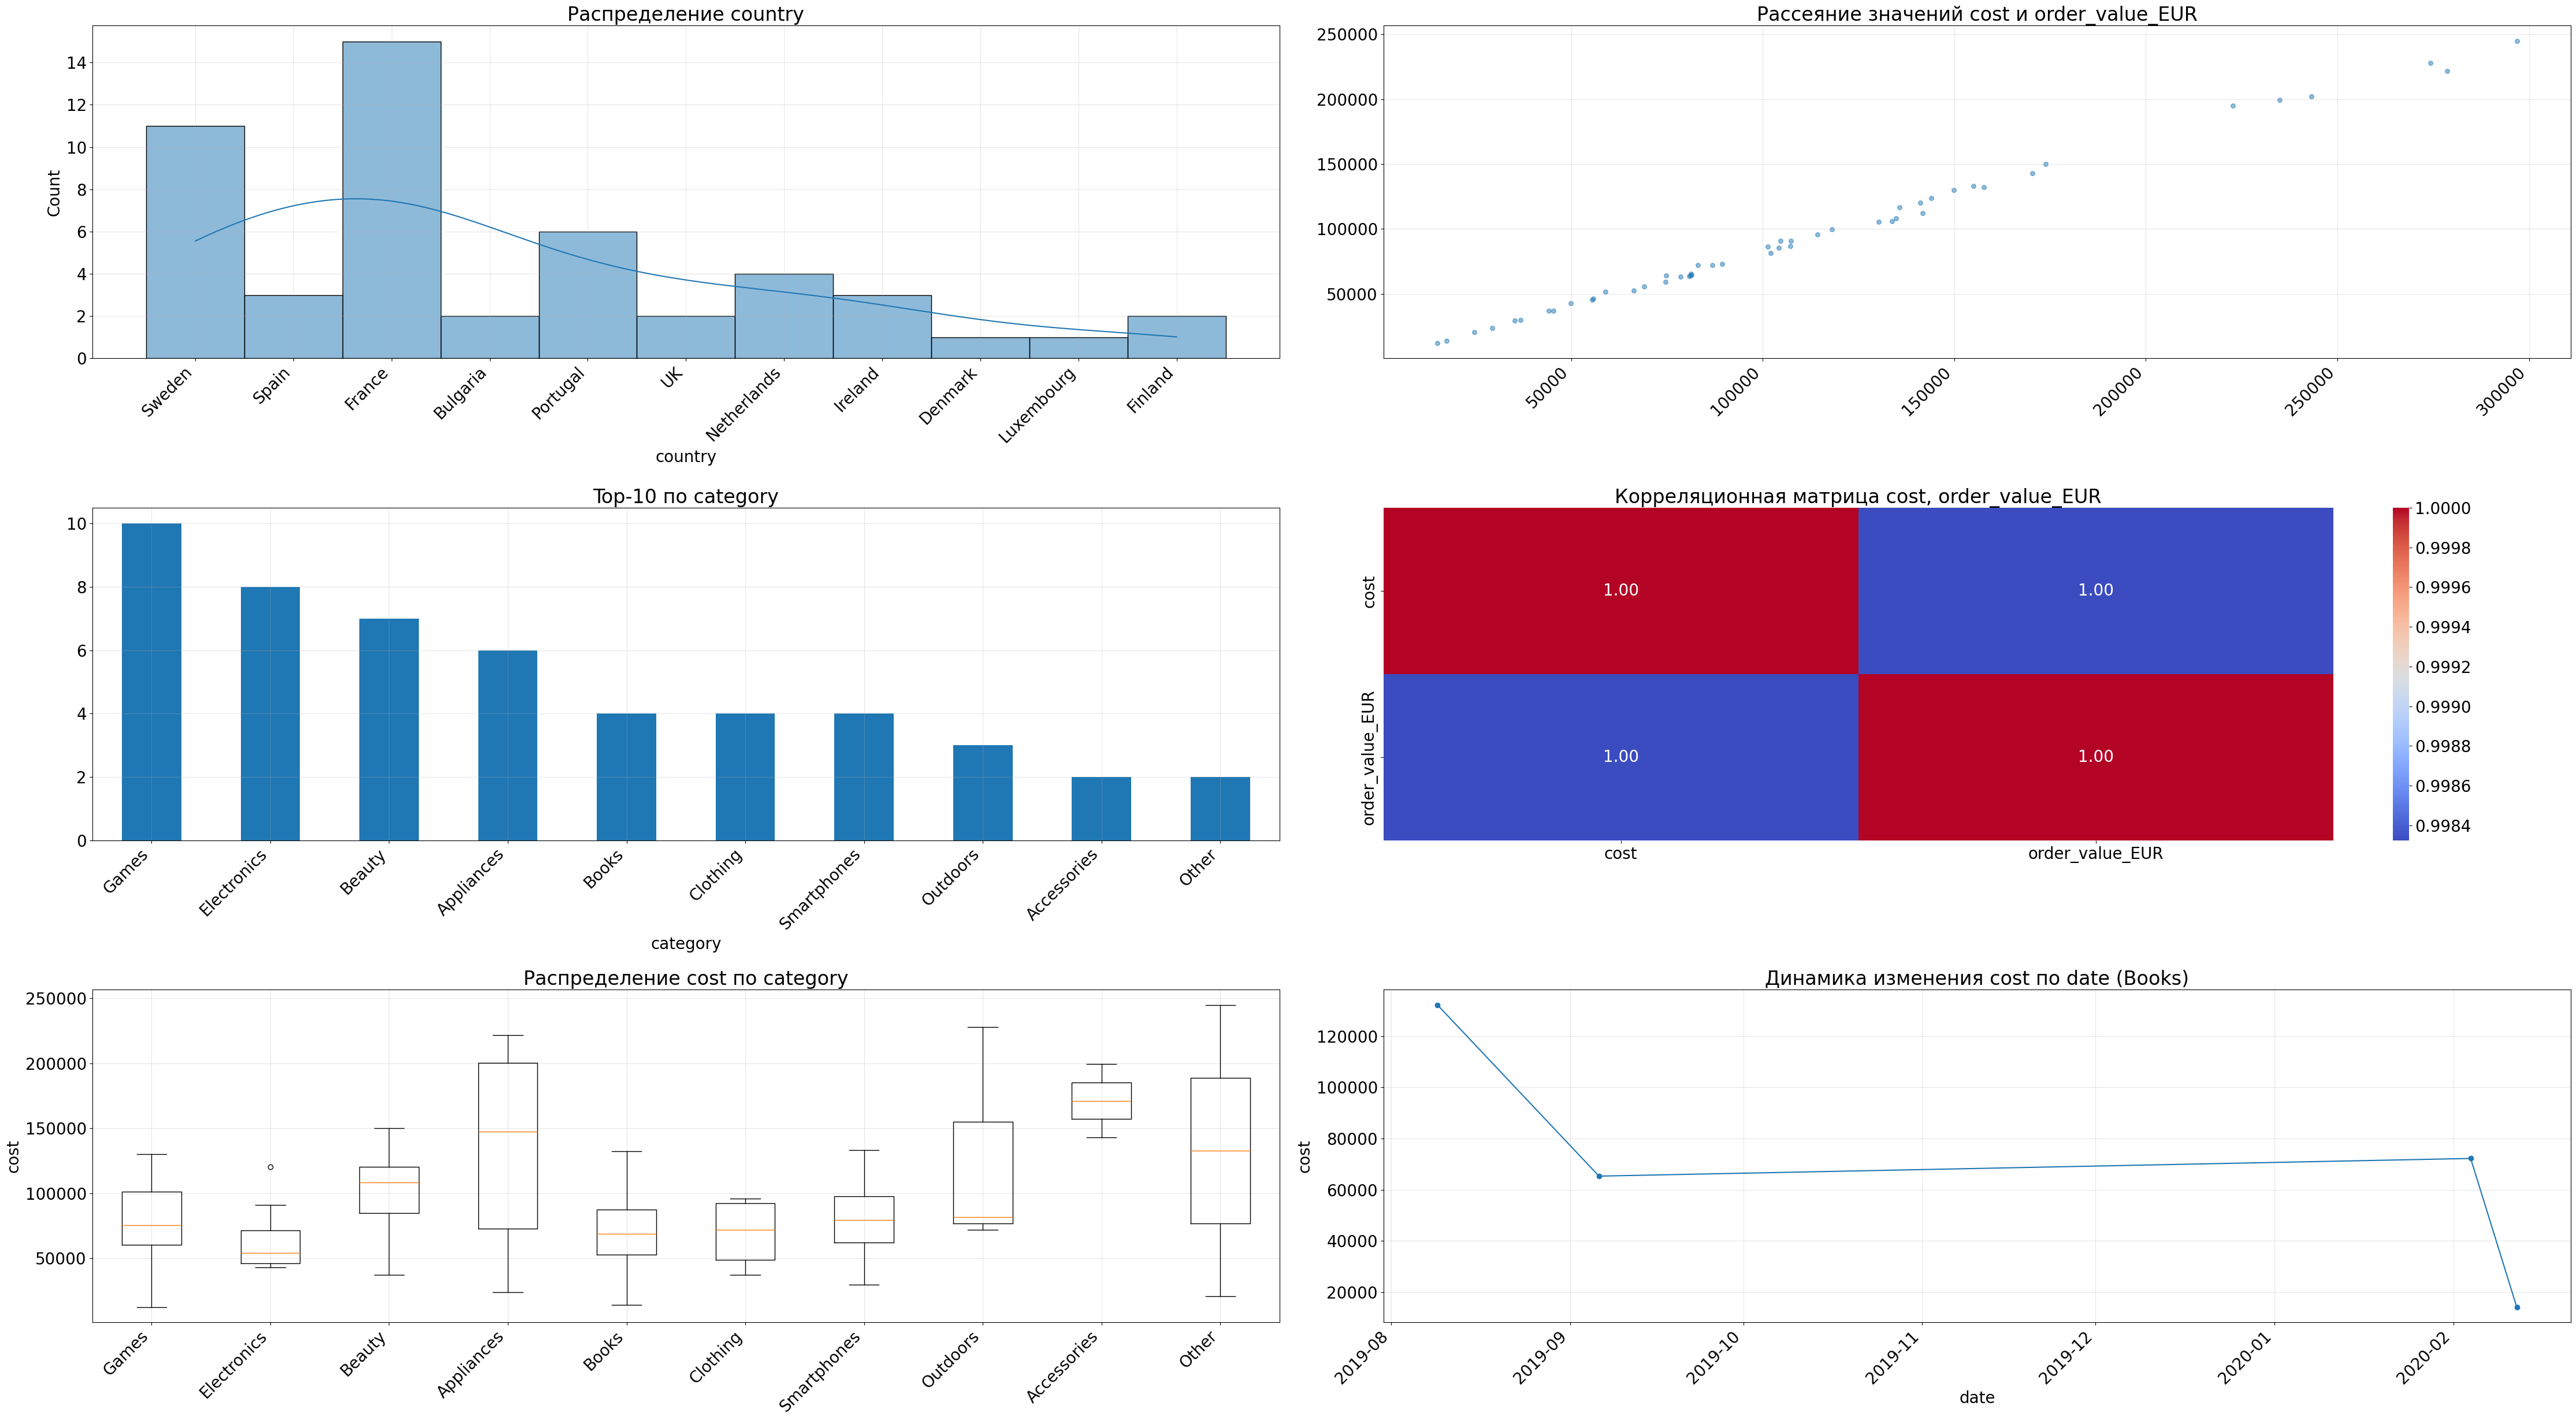

In [20]:
# Активация класса по визуализации данных

viz = DataVisualizer(df)

# Список графиков
plots = [
    (viz.histogram, ('country', 20)),
    (viz.scatter, ('order_value_EUR', 'cost')),
    (viz.bar, ('category', 10)),
    (viz.correlation, (['cost', 'order_value_EUR'],)),
    (viz.boxplot, ('cost', 'category')),
    (viz.line_chart, ('date', 'cost', 'Books'))
]

viz.show_grid(plots, cols=2, figsize=(45, 25), step=20, font_scale=2.0)